## Run the YAML pipeline

Execute this cell first to (re)generate results from `mfx101609126_pershot_xes.yaml`.  
Skip if results are already up-to-date.

In [1]:
import sys, os
sys.path.insert(0, '..')

import h5py
import numpy as np
from XSpect.controller.pipeline import Pipeline

pipeline = Pipeline.from_yaml('mfx101609126_pershot_xes.yaml')
pipeline.run(cores=1, batch_size=100000)

# Save results to HDF5 (Pipeline collects results but doesn't write to disk)
out_dir = pipeline.config.output.path
os.makedirs(out_dir, exist_ok=True)
run_num = pipeline.config.data.runs[0]
out_file = os.path.join(out_dir, f'run{run_num:04d}.h5')

with h5py.File(out_file, 'w') as f:
    for key, value in pipeline.results.items():
        if isinstance(value, np.ndarray):
            f.create_dataset(key, data=value)
            print(f'  saved: {key} {value.shape}')

print(f'\nOutput written to: {out_file}')

  saved: ipm (2843,)
  saved: xrt_hproj (2843, 2048)
  saved: epix_seer_col_profile (620,)
  saved: epix_seer_col_baseline (620,)
  saved: epix_seer_col_zscore (620,)
  saved: epix_spec_ROI_1 (2843, 300)
  saved: epix_seer_ROI_1 (2843, 620)

Output written to: ./results/mfx101609126_pershot_xes/run0079.h5


# Pixel Patch Diagnostic — mfx101609126 run 79

Compares **raw** smalldata (pre-patch) to the **pipeline output** HDF5 (post-patch).  
Patched pixels for `epix_spec`: cols 80-81, 176-177, 275-276 (manual).  
Patched pixels for `epix_seer`: auto-detected via combined ratio + z-score method.

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# ── Paths ──────────────────────────────────────────────────────────────────
SMD_PATH = '/sdf/data/lcls/ds/mfx/mfx101609126/hdf5/smalldata/mfx101609126_Run0079.h5'
OUT_PATH = './results/mfx101609126_pershot_xes/run0079.h5'

# ── Known gap pixels (from YAML) ──────────────────────────────────────────
SPEC_PIXELS = [80, 81, 176, 177, 273, 274]
SIGNAL_ROWS = {'epix_spec': (10, 40), 'epix_seer': (50, 90)}
ADU_THRESH  = 5.0

## 1. Load pipeline output and raw data

In [3]:
# Load pipeline output (post-patch, post-rotate, post-spatial-reduce)
with h5py.File(OUT_PATH, 'r') as f:
    print('Output HDF5 keys:')
    for k in f.keys():
        ds = f[k]
        print(f'  {k}: {ds.shape if hasattr(ds, "shape") else ds}')
    
    spec_patched = f['epix_spec_ROI_1'][:]   # (N_xray, 300) — post-patch 1D spectra
    seer_patched = f['epix_seer_ROI_1'][:]   # (N_xray, 620)
    ipm = f['ipm'][:]
    
    # Load patched pixel lists if present
    spec_auto = f['epix_spec_auto_patched_pixels'][:] if 'epix_spec_auto_patched_pixels' in f else []
    seer_auto = f['epix_seer_auto_patched_pixels'][:] if 'epix_seer_auto_patched_pixels' in f else []

print(f'\nPost-patch spectra: spec {spec_patched.shape}, seer {seer_patched.shape}')
print(f'Auto-detected pixels: spec={list(spec_auto)}, seer={list(seer_auto)}')

Output HDF5 keys:
  epix_seer_ROI_1: (2843, 620)
  epix_seer_col_baseline: (620,)
  epix_seer_col_profile: (620,)
  epix_seer_col_zscore: (620,)
  epix_spec_ROI_1: (2843, 300)
  ipm: (2843,)
  xrt_hproj: (2843, 2048)

Post-patch spectra: spec (2843, 300), seer (2843, 620)
Auto-detected pixels: spec=[], seer=[]


In [4]:
# Load raw smalldata for "before" comparison
# Build the same projection that the pipeline produces (signal-row sum)
# but WITHOUT patching
with h5py.File(SMD_PATH, 'r') as f:
    xray = f['lightStatus/xray'][:].astype(bool)
    N = len(xray)
    
    # epix_spec: sum signal rows (10-40) for xray-on shots
    spec_raw_proj = np.zeros((xray.sum(), f['epix100_0/ROI_area'].shape[2]), dtype=np.float64)
    seer_raw_proj = np.zeros((xray.sum(), f['epix100_1/ROI_area'].shape[2]), dtype=np.float64)
    
    r0s, r1s = SIGNAL_ROWS['epix_spec']
    r0e, r1e = SIGNAL_ROWS['epix_seer']
    
    chunk = 5000
    xray_idx = 0
    for start in range(0, N, chunk):
        end = min(start + chunk, N)
        xmask = xray[start:end]
        n_xray = xmask.sum()
        if n_xray == 0:
            continue
        
        # epix_spec
        raw = f['epix100_0/ROI_area'][start:end][xmask].astype(np.float64)
        raw[raw < ADU_THRESH] = 0.0
        spec_raw_proj[xray_idx:xray_idx+n_xray] = raw[:, r0s:r1s, :].sum(axis=1)
        
        # epix_seer
        raw = f['epix100_1/ROI_area'][start:end][xmask].astype(np.float64)
        raw[raw < ADU_THRESH] = 0.0
        seer_raw_proj[xray_idx:xray_idx+n_xray] = raw[:, r0e:r1e, :].sum(axis=1)
        
        xray_idx += n_xray
        print(f'  Loaded shots {start}-{end} ({n_xray} xray)', end='\r')

print(f'\nRaw projections: spec {spec_raw_proj.shape}, seer {seer_raw_proj.shape}')

  Loaded shots 0-5000 (367 xray)  Loaded shots 5000-10000 (386 xray)  Loaded shots 10000-15000 (424 xray)  Loaded shots 15000-20000 (418 xray)  Loaded shots 20000-25000 (401 xray)  Loaded shots 25000-30000 (375 xray)  Loaded shots 30000-35000 (410 xray)  Loaded shots 35000-35998 (62 xray)
Raw projections: spec (2843, 300), seer (2843, 620)


## 2. Before vs After — mean 1D spectra

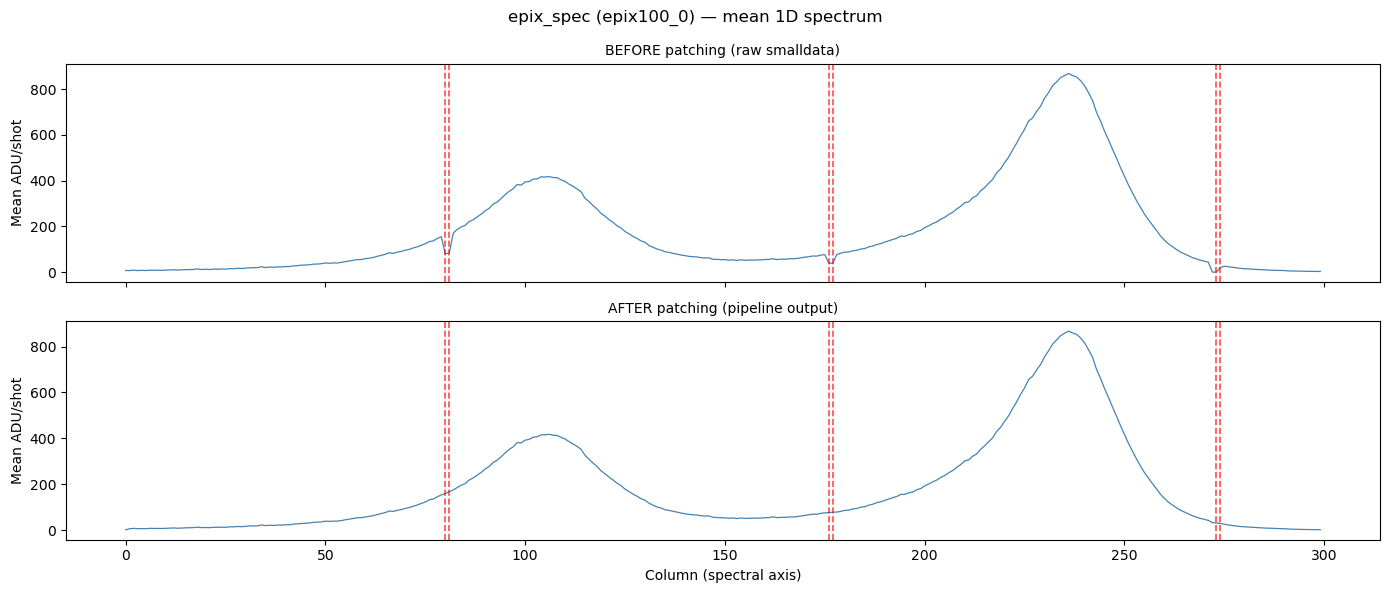

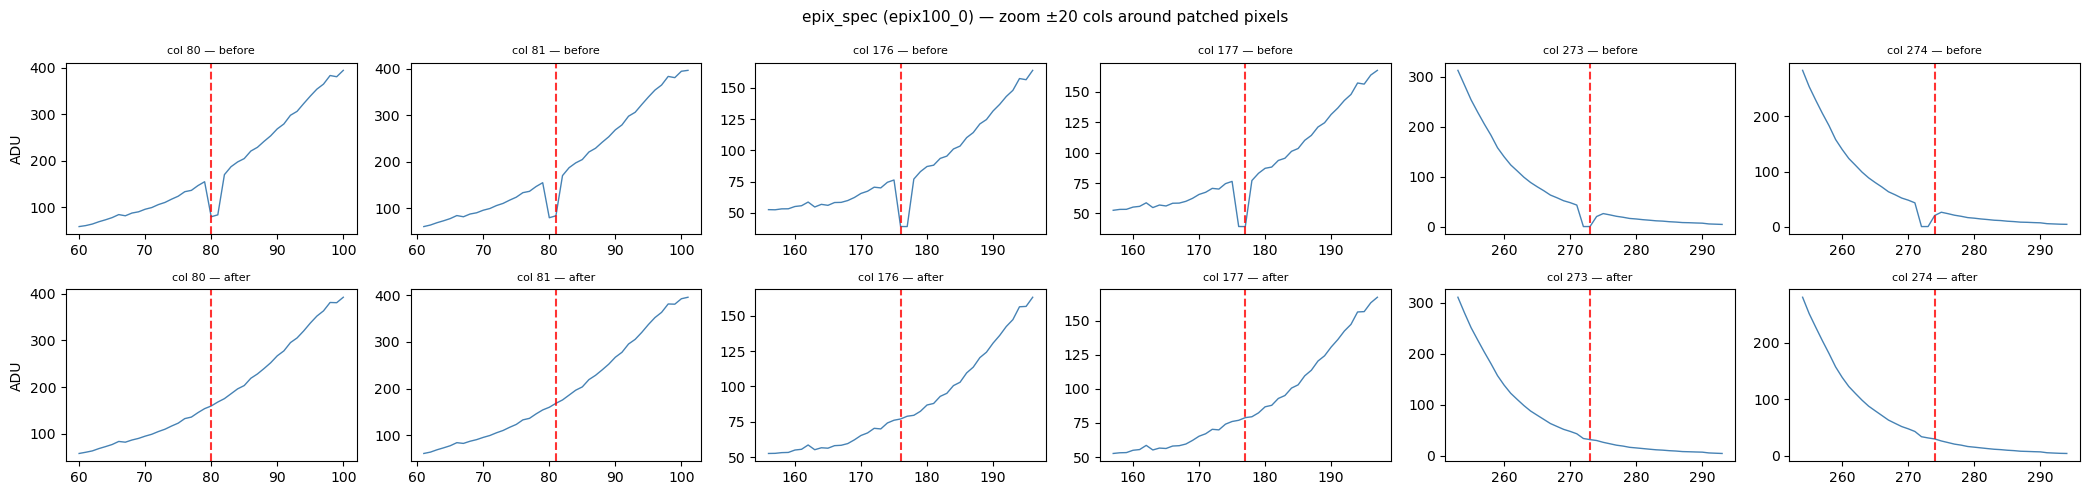

In [5]:
def plot_before_after(raw_proj, patched_proj, pixels, det_label):
    """Compare mean spectrum before (raw) and after (pipeline output)."""
    before = raw_proj.mean(axis=0)
    after = patched_proj.mean(axis=0)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
    fig.suptitle(f'{det_label} — mean 1D spectrum', fontsize=12)
    
    for ax, data, title in zip(axes, [before, after],
                                ['BEFORE patching (raw smalldata)', 'AFTER patching (pipeline output)']):
        ax.plot(data, lw=0.9, color='steelblue')
        for c in pixels:
            ax.axvline(c, color='red', lw=1.2, alpha=0.7, ls='--')
        ax.set_ylabel('Mean ADU/shot')
        ax.set_title(title, fontsize=10)
    
    axes[-1].set_xlabel('Column (spectral axis)')
    plt.tight_layout()
    plt.show()
    
    # Zoomed panels
    if not pixels:
        return
    n_show = min(len(pixels), 8)
    show = pixels[:n_show]
    fig, axes = plt.subplots(2, n_show, figsize=(3.5*n_show, 5))
    if n_show == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(f'{det_label} — zoom ±20 cols around patched pixels', fontsize=11)
    
    for ci, c in enumerate(show):
        lo, hi = max(0, c-20), min(len(before), c+21)
        xi = np.arange(lo, hi)
        for ri, (d, lbl) in enumerate([(before, 'before'), (after, 'after')]):
            ax = axes[ri, ci]
            ax.plot(xi, d[lo:hi], lw=1.0, color='steelblue')
            ax.axvline(c, color='red', lw=1.5, ls='--', alpha=0.8)
            ax.set_title(f'col {c} — {lbl}', fontsize=8)
            if ci == 0:
                ax.set_ylabel('ADU')
    plt.tight_layout()
    plt.show()


plot_before_after(spec_raw_proj, spec_patched, SPEC_PIXELS, 'epix_spec (epix100_0)')

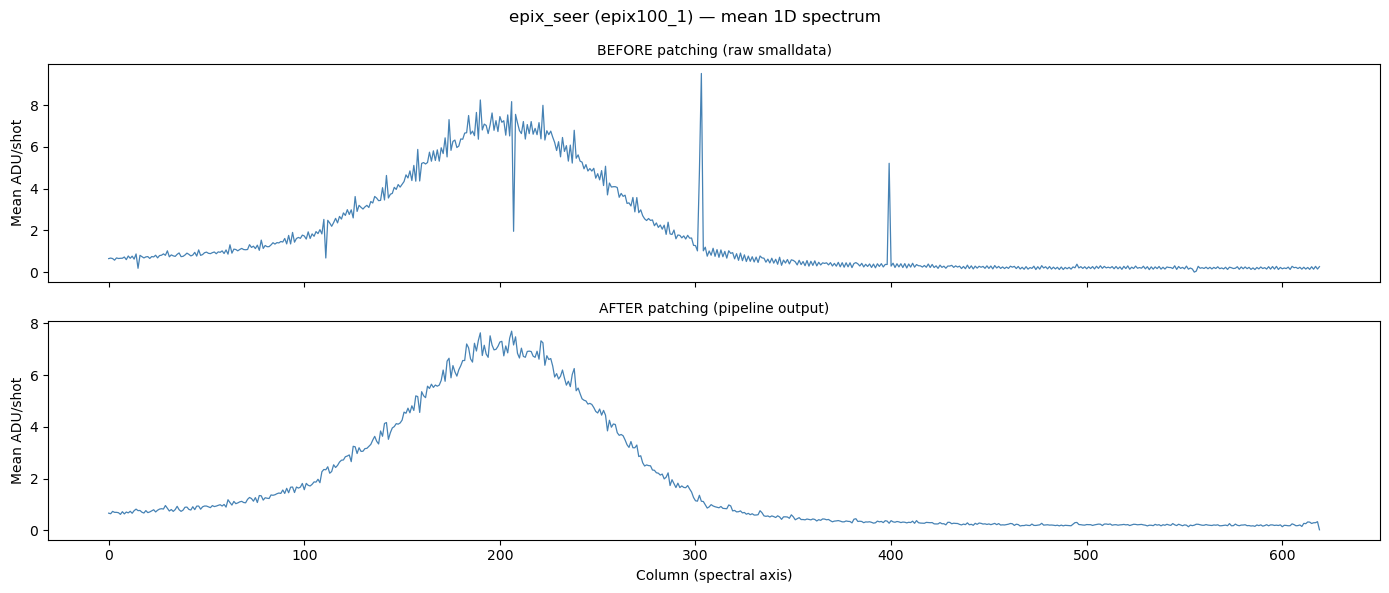

In [6]:
seer_pixels = list(seer_auto) if len(seer_auto) > 0 else []
plot_before_after(seer_raw_proj, seer_patched, seer_pixels, 'epix_seer (epix100_1)')

## 3. Summed 2D ROI image (raw) with gap locations marked

In [7]:
# Build 2D summed images from raw data
with h5py.File(SMD_PATH, 'r') as f:
    xray = f['lightStatus/xray'][:].astype(bool)
    N = len(xray)
    
    spec_sum2d = np.zeros(f['epix100_0/ROI_area'].shape[1:], dtype=np.float64)
    seer_sum2d = np.zeros(f['epix100_1/ROI_area'].shape[1:], dtype=np.float64)
    
    chunk = 5000
    for start in range(0, N, chunk):
        end = min(start + chunk, N)
        xmask = xray[start:end]
        if xmask.sum() == 0:
            continue
        
        raw = f['epix100_0/ROI_area'][start:end][xmask].astype(np.float64)
        raw[raw < ADU_THRESH] = 0.0
        spec_sum2d += raw.clip(0).sum(axis=0)
        
        raw = f['epix100_1/ROI_area'][start:end][xmask].astype(np.float64)
        raw[raw < ADU_THRESH] = 0.0
        seer_sum2d += raw.clip(0).sum(axis=0)
        
        print(f'  shots {start}-{end}', end='\r')

print(f'\nspec_sum2d: {spec_sum2d.shape}, seer_sum2d: {seer_sum2d.shape}')

  shots 0-5000  shots 5000-10000  shots 10000-15000  shots 15000-20000  shots 20000-25000  shots 25000-30000  shots 30000-35000  shots 35000-35998
spec_sum2d: (60, 300), seer_sum2d: (100, 620)


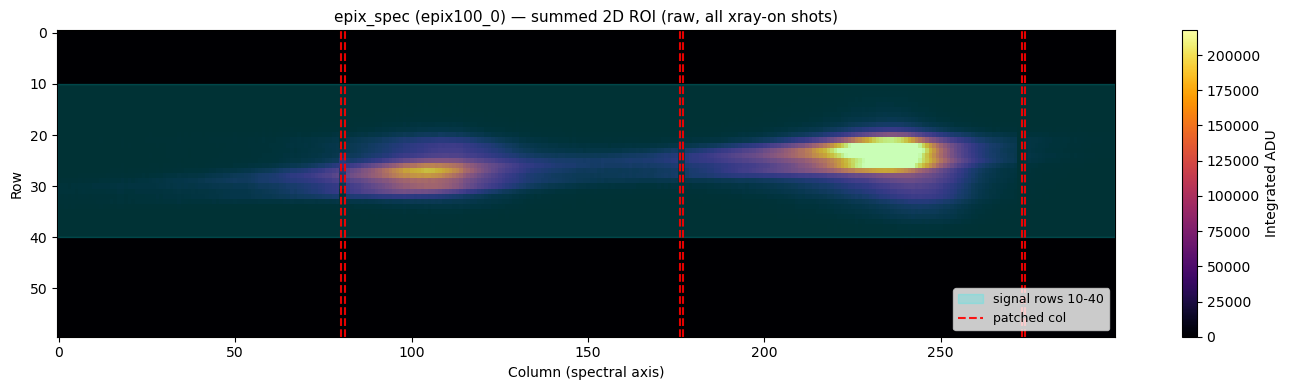

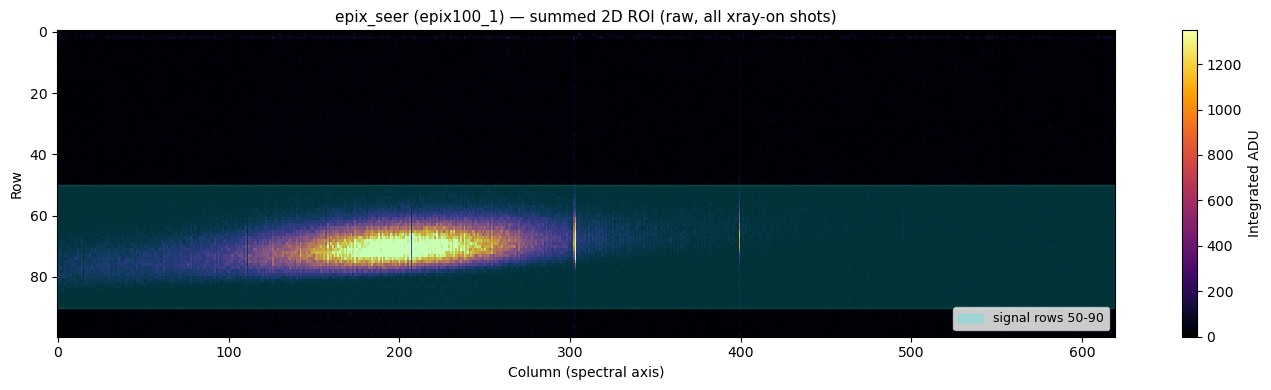

In [8]:
def plot_2d_with_gaps(sum2d, pixels, signal_rows, det_label):
    fig, ax = plt.subplots(1, 1, figsize=(14, 4))
    vmax = np.percentile(sum2d, 99.5)
    im = ax.imshow(sum2d, aspect='auto', origin='upper', cmap='inferno',
                   vmin=0, vmax=vmax, interpolation='nearest')
    plt.colorbar(im, ax=ax, label='Integrated ADU')
    
    r0, r1 = signal_rows
    ax.axhspan(r0, r1, color='cyan', alpha=0.2, label=f'signal rows {r0}-{r1}')
    for i, c in enumerate(pixels):
        ax.axvline(c, color='red', lw=1.5, ls='--', alpha=0.9,
                   label='patched col' if i == 0 else '_')
    
    ax.set_xlabel('Column (spectral axis)')
    ax.set_ylabel('Row')
    ax.set_title(f'{det_label} — summed 2D ROI (raw, all xray-on shots)', fontsize=11)
    ax.legend(fontsize=9, loc='lower right')
    plt.tight_layout()
    plt.show()


plot_2d_with_gaps(spec_sum2d, SPEC_PIXELS, SIGNAL_ROWS['epix_spec'], 'epix_spec (epix100_0)')
plot_2d_with_gaps(seer_sum2d, list(seer_auto), SIGNAL_ROWS['epix_seer'], 'epix_seer (epix100_1)')

## 4. Quantitative check — patched pixel values vs neighbors

In [9]:
def quantitative_check(raw_proj, patched_proj, pixels, det_label):
    before = raw_proj.mean(axis=0)
    after = patched_proj.mean(axis=0)
    bad_set = set(pixels)
    
    print(f'\n{det_label}')
    print(f'{"col":>5} {"before":>10} {"after":>10} {"neighbors":>10} {"after/nbr":>10}')
    print('-' * 52)
    for c in pixels:
        # Clean neighbors: ±10 but >4 away from any bad pixel
        clean = [i for i in range(max(c-10, 0), min(c+11, len(before)))
                 if i not in bad_set and all(abs(i-b) > 4 for b in bad_set)]
        n_avg = np.mean(before[clean]) if clean else 0
        ratio = f'{after[c]/n_avg:.1%}' if n_avg > 0 else 'n/a'
        print(f'{c:>5} {before[c]:>10.2f} {after[c]:>10.2f} {n_avg:>10.2f} {ratio:>10}')


quantitative_check(spec_raw_proj, spec_patched, SPEC_PIXELS, 'epix_spec (epix100_0)')
quantitative_check(seer_raw_proj, seer_patched, list(seer_auto), 'epix_seer (epix100_1)')


epix_spec (epix100_0)
  col     before      after  neighbors  after/nbr
----------------------------------------------------
   80      79.93     159.90     169.84      94.1%
   81      84.05     168.34     186.48      90.3%
  176      39.18      76.94      79.63      96.6%
  177      39.14      78.88      84.71      93.1%
  273       0.20      31.64      48.25      65.6%
  274      20.27      29.84      40.26      74.1%

epix_seer (epix100_1)
  col     before      after  neighbors  after/nbr
----------------------------------------------------
